# Dispersion-Assisted Phase Recovery — Visual Gallery II

Five *new* graph types for the same synthetic field, leaning into time-frequency and 3-D:

1. **Spectrogram** — the chirp as a sloped ridge.
2. **Wigner-Ville distribution** — the sharper time-frequency portrait (with its tell-tale cross-terms).
3. **Dispersion-diversity map** — which dispersion pairs $(D_1,D_2)$ make phase retrieval *solvable*.
4. **3-D stretch surface** — the pulse fanning out, as a landscape.
5. **Instantaneous frequency** — the derivative of the phase, the thing the chirp encodes.

Saved to `figures/`. Civilian optical-metrology data from `dispersion_gs_prototype.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import dispersion_gs_prototype as dg

root = pathlib.Path.cwd().parent; (root / "figures").mkdir(exist_ok=True)
data = dg.make_measurements(N=1024, D=6000.0, seed=7)
t, x, A, phi = data["t"], data["x"], data["A"], data["phi"]
print("field loaded, N =", len(t))

field loaded, N = 1024


## 1 — Spectrogram

Short-time Fourier transform: slide a window, FFT each slice. A chirp (frequency ramping with time)
shows up as a **diagonal ridge** — you can literally see the instantaneous frequency sweep.

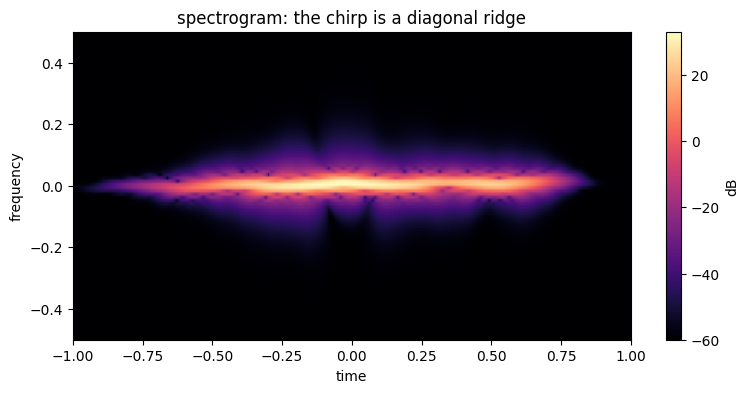

In [2]:
def spectrogram(sig, win=96, hop=2):
    w = np.hanning(win)
    cols = range(0, len(sig) - win, hop)
    return np.array([np.abs(np.fft.fftshift(np.fft.fft(sig[i:i+win]*w)))**2 for i in cols]).T

S = spectrogram(x)
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(10*np.log10(S + 1e-6), aspect="auto", origin="lower", cmap="magma",
               extent=[t[0], t[-1], -0.5, 0.5])
fig.colorbar(im, ax=ax, label="dB"); ax.set_xlabel("time"); ax.set_ylabel("frequency")
ax.set_title("spectrogram: the chirp is a diagonal ridge")
fig.savefig(root / "figures" / "gallery2_spectrogram.png", dpi=120); plt.show()

## 2 — Wigner-Ville distribution

The highest-resolution time-frequency portrait: $W(t,\omega)=\int x(t+\tfrac\tau2)x^*(t-\tfrac\tau2)
e^{-i\omega\tau}\,d\tau$. The chirp becomes a crisp tilted line; the second pulse adds its own, and the
**oscillating cross-term** between them is the Wigner signature of two coherent components.

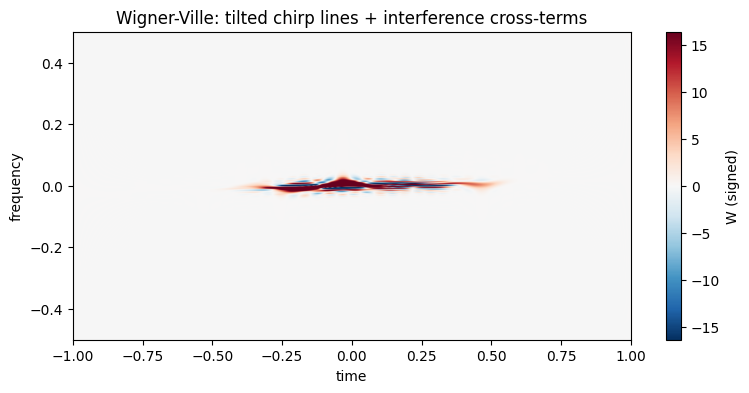

In [3]:
def wigner_ville(sig):
    N = len(sig); W = np.zeros((N, N), dtype=complex)
    for n in range(N):
        m = min(n, N-1-n, N//2 - 1)
        tau = np.arange(-m, m+1)
        lag = np.zeros(N, dtype=complex)
        lag[tau % N] = sig[n+tau] * np.conj(sig[n-tau])
        W[:, n] = np.fft.fft(lag)
    return np.real(np.fft.fftshift(W, axes=0))

W = wigner_ville(x)
fig, ax = plt.subplots(figsize=(9, 4))
v = np.percentile(np.abs(W), 99.5)
im = ax.imshow(W, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-v, vmax=v,
               extent=[t[0], t[-1], -0.5, 0.5])
fig.colorbar(im, ax=ax, label="W (signed)"); ax.set_xlabel("time"); ax.set_ylabel("frequency")
ax.set_title("Wigner-Ville: tilted chirp lines + interference cross-terms")
fig.savefig(root / "figures" / "gallery2_wigner.png", dpi=120); plt.show()

## 3 — Dispersion-diversity map

The practical one: for each pair of dispersions $(D_1,D_2)$, how *correlated* are the two measured
intensities? Bright (corr $\to 1$) means redundant measurements and **unsolvable** phase; dark means
diverse measurements and **recoverable** phase. The diagonal is 1 by construction; the useful region
is the dark corners — a map of where the carrier-less receiver works.

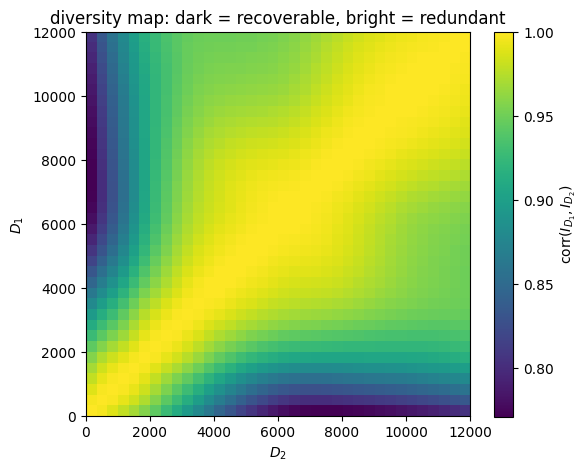

most diverse pair |D| ~ 7199


In [4]:
Ds = np.linspace(0, 12000, 36)
M = np.zeros((len(Ds), len(Ds)))
Idisp = [np.abs(dg.disperse(x, D))**2 for D in Ds]
for i in range(len(Ds)):
    for j in range(len(Ds)):
        M[i, j] = np.corrcoef(Idisp[i], Idisp[j])[0, 1]
fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(M, origin="lower", cmap="viridis", extent=[Ds[0], Ds[-1], Ds[0], Ds[-1]])
fig.colorbar(im, ax=ax, label="corr($I_{D_1}, I_{D_2}$)")
ax.set_xlabel("$D_2$"); ax.set_ylabel("$D_1$")
ax.set_title("diversity map: dark = recoverable, bright = redundant")
fig.savefig(root / "figures" / "gallery2_diversity.png", dpi=120); plt.show()
print("most diverse pair |D| ~", int(Ds[np.unravel_index(M[1:,1:].argmin(), M[1:,1:].shape)[0]+1]))

## 4 — The dispersion stretch as a 3-D landscape

The same stretch as gallery I, but lifted into a surface: time and dispersion on the floor, intensity
as height — the pulse spreading into a ridge.

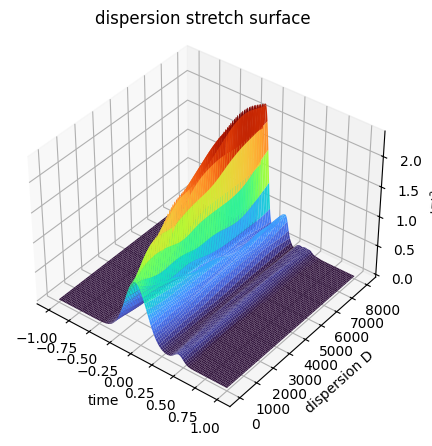

In [5]:
Dg = np.linspace(0, 8000, 80)
Z = np.array([np.abs(dg.disperse(x, D))**2 for D in Dg])
T2, D2 = np.meshgrid(t, Dg)
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(T2, D2, Z, cmap="turbo", linewidth=0, antialiased=True, rcount=80, ccount=120)
ax.set_xlabel("time"); ax.set_ylabel("dispersion D"); ax.set_zlabel("$|E|^2$")
ax.set_title("dispersion stretch surface"); ax.view_init(38, -52)
fig.savefig(root / "figures" / "gallery2_surface.png", dpi=120); plt.show()

## 5 — Instantaneous frequency

The phase's derivative $\frac{1}{2\pi}\frac{d\phi}{dt}$ is the instantaneous frequency — what the chirp
*is*. Plotted under the amplitude envelope (so you see it only where there's signal), it's the clean,
1-D essence of everything the time-frequency pictures show.

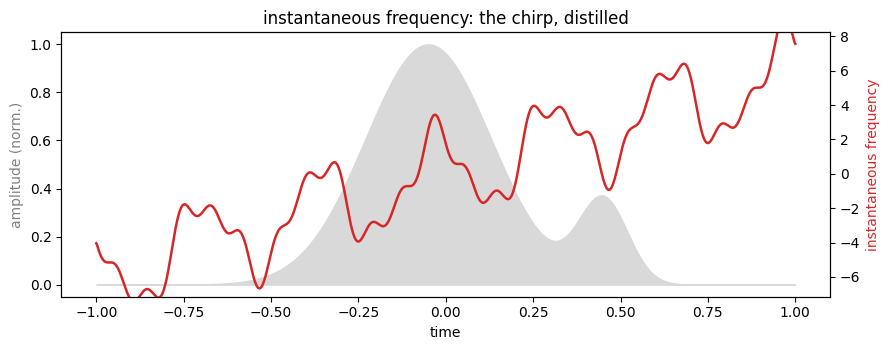

saved 5 figures to figures/gallery2_*.png


In [6]:
inst_f = np.gradient(np.unwrap(phi), t) / (2*np.pi)
fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.fill_between(t, 0, A/A.max(), color="0.85", label="|x| (envelope)")
ax1.set_xlabel("time"); ax1.set_ylabel("amplitude (norm.)", color="0.5")
ax2 = ax1.twinx()
ax2.plot(t, inst_f, "C3", lw=1.8, label="inst. frequency $d\\phi/dt$")
ax2.set_ylabel("instantaneous frequency", color="C3"); ax2.set_ylim(np.percentile(inst_f, [2, 98]))
ax1.set_title("instantaneous frequency: the chirp, distilled")
fig.tight_layout(); fig.savefig(root / "figures" / "gallery2_instfreq.png", dpi=120); plt.show()
print("saved 5 figures to figures/gallery2_*.png")

## Files

`figures/gallery2_*.png` — spectrogram, Wigner-Ville, diversity map, 3-D surface, instantaneous
frequency. The **diversity map** is the one to keep on the wall: it tells you, before you build the
optics, which dispersion pair will actually let you recover the phase.